# NLP 2026
# Lab 5: Prompting Large Language Models

LLMs are everywhere nowadays. You have probably used their many times and have seen their results. You might have seen good and bad results and that often how you ask the model to do something makes a big difference.
In this lab we will have a closer look at the prompting of LLMs. While often you would need to fine-tune the model for a specific task, you will see that prompting can be a powerful tool to shape the models responses.

An important distinction between this and the previous labs is that you will have to prepare a video presentation. You will find more information in the notebook.

By the end of this lab you should be able to:
- Load a pre-trained LLM
- Use the LLM to generate text
- Experiment with different prompting strategies
- Use the LLM to generate text based on the dataset
- Evaluate the generated text



### Exercises

In this lab the exercises are not graded. We will only grade the final video presentation. You can find the instructions in the last exercise ([Exercise 7](#e7)). The other exercises are there to guide you, and you should complete them as well, but they are not graded directly.

| Exercise          |
|-------------------|
| [Exercise 1](#e1) |
| [Exercise 2](#e2) |
| [Exercise 3](#e3) |
| [Exercise 4](#e4) |
| [Exercise 5](#e5) |
| [Exercise 6](#e6) |
| [Exercise 7](#e7) |

The maximum grade for this lab is 0.6 points.

### 📌 **Instructions for Delivery** (📅 **Deadline: 13/Mar 18:00**, 🎭 *wildcards possible*)

✅ **Submission Requirements**
+ 📄 You need to submit a **video presentation** that is no longer than 5 minutes and a **copy of your notebook** 📓 with the code.
+ ⚡ Make sure that **all cells are executed properly** ⚙️ and that **all figures/results/plots** 📊 you include in the presentation are also visible in your **executed notebook**.

✅ **Collaboration & Integrity**
+ 🗣️ While you may **discuss** the lab with others, you must **write your solutions with your group only**. If you **discuss specific tasks** with others, please **include their names** in the appendix of the report.
+ 📜 **Honor Code applies** to this lab. For more details, check **Syllabus §7.2** ⚖️.
+ 📢 **Mandatory Disclosure**:
   - Any **websites** 🌐 (e.g., **Stack Overflow** 💡) or **other resources** used must be **listed and disclosed**.
   - Any **GenAI tools** 🤖 (e.g., **ChatGPT**) used must be **explicitly mentioned**.
   - 🚨 **Failure to disclose these resources is a violation of academic integrity**. See **Syllabus §7.3** for details.

Collaborators: list collaborators here

**I talked with Jerry about...**

Use of genAI tools (e.g. chatGPT), websites (e.g. stackoverflow): list websites where you found code (or other info) as well as include information on how you used genAI tools (e.g. prompts):

I asked chatGPT about...

We used Claude primarily for ideas structure of the prompts. We double-checked with Gemini if the prompts are okay and if it would work with our exercises.
We used Claude also for coding and explaining how the code works step-by-step so we achieve better understanding

## 0. Setup
We start by making sure we have everything we need for this lab.


### 0.1 Using Google Colab

In this lab we will be generating text using LLMs. While we choose the small models for the exercises, they are still quite large and require a lot of memory. We recommend using google colab for this lab but you can also run it on your local machine if you have a GPU.

As mentioned before, Google Colab [https://colab.google/](https://colab.google/) gives you access to a GPU for a limited time (after you used this time you will have to wait for some time to use it again). To use a GPU you need to select the runtime type. Go to "Runtime -> Change runtime type". There you can select a CPU or a GPU.

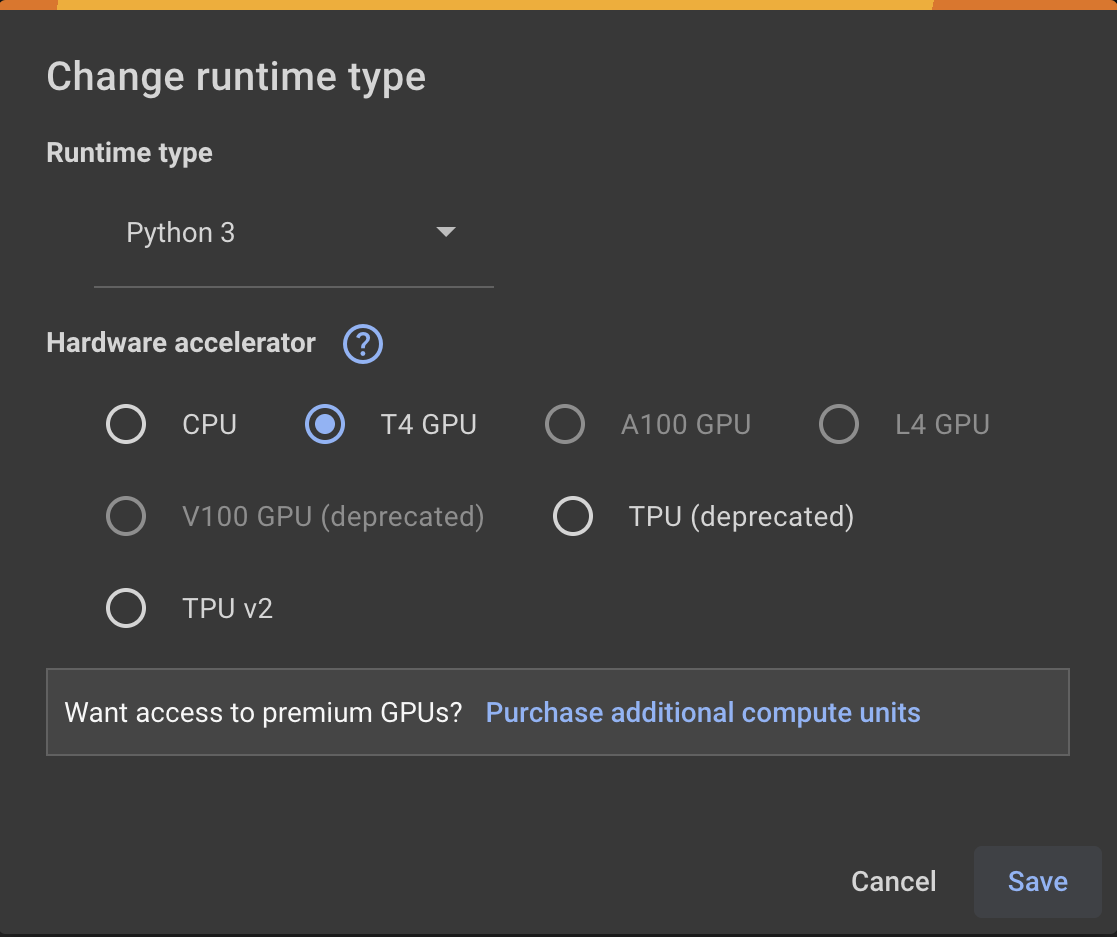

### 0.2 Installs and Imports

The following cell installs the required packages. You can run it if you are using Google Colab or if you are missing any of the packages. If you are using a local environment, you can copy the commands and run them in your terminal.

In [ ]:
! pip install -U datasets
! pip install torch torchvision torchaudio
! pip install transformers
! pip install accelerate
! pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.5 MB/s eta 0:00:00


In [ ]:
! pip list | grep -E 'torch|transformers|datasets|accelerate'

accelerate                               1.13.0
datasets                                 4.7.0
sentence-transformers                    5.2.3
tensorflow-datasets                      4.9.9
torch                                    2.10.0+cu128
torchao                                  0.10.0
torchaudio                               2.10.0+cu128
torchcodec                               0.10.0+cu128
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.0+cu128
transformers                             5.0.0
vega-datasets                            0.9.0


As usual, we start by importing some essential Python libraries that we will be using.

In [ ]:
import math

import numpy as np
import matplotlib.pyplot as plt
import datasets
import transformers
import tqdm
import torch
import sacrebleu

## 1. Load and Preprocess Data

In this lab we will look at the task of summarization. The goal is to summarize a long text into a short form that encapsulates the meaning and the key information.

The dataset we are going to use can be found on [Huggingface](https://huggingface.co/datasets/EdinburghNLP/xsum). It contains documents and their summaries, aka it is a parallel corpus of documents and their equivalent summaries.

For example, for the document

`"The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail."`

the summary (based on the dataset) is:

`"Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud."`.


For more information you can read the original paper (from the University of Edinburgh) [here](https://aclanthology.org/D18-1206/).

### 1.1 Loading the Dataset

The dataset will be loaded as a huggingface dataset. We are going to limit the number of examples from each split, as the documents can be relatively long. You will thank me later, when you see how compute-hungry LLMs can be.

Make sure to inspect the dataset and make sure it is imported properly.

In [ ]:
ds = datasets.load_dataset("EdinburghNLP/xsum", split=['train[0:200]', 'validation[0:200]', 'test[0:200]'])
ds = datasets.DatasetDict({
    'train': ds[0],
    'validation': ds[1],
    'test': ds[2],
})
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
})


In [ ]:
for i in range(10):
    print(ds['validation'][i])

{'document': 'The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.\nMr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.\nAppearing at the Old Bailey earlier, all four denied the offence.\nThe charge relates to offences which allegedly took place between 2008 and 2014.\nSam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.\nThey were all released on bail.', 'summary': 'Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.', 'id': '38295789'}
{'document': 'Voges was forced to retire hurt on 86 after suffering the injury while batting during the County Championship draw with Somerset on 4 June.\nMiddlesex hope to have the Australian back for their T20 Blast game against Hampshire at Lord\'s on 3 August.\nThe 37-year-old has scored 230 runs in

As in previous lab, we will be using the pre-trained tokenizer, so we can omit the cleaning process. You can still add it if you want more control over the data.

In [ ]:
### YOUR CODE HERE
print("Dataset splits:", ds)
print("\nColumns:", ds["validation"].column_names)
print("\nExample document (first 300 chars):")
print(ds["validation"][0]["document"][:300])
print("\nExample summary:")
print(ds["validation"][0]["summary"])
print("\nSummary lengths (words) for first 10 validation examples:")
for i in range(10):
    doc = ds["validation"][i]["document"]
    summ = ds["validation"][i]["summary"]
    print(f"  Doc {i}: {len(doc.split())} words -> Summary: {len(summ.split())} words")
### YOUR CODE ENDS HERE


Dataset splits: DatasetDict({
    train: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
    test: Dataset({
        features: ['document', 'summary', 'id'],
        num_rows: 200
    })
})

Columns: ['document', 'summary', 'id']

Example document (first 300 chars):
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.

Example summary:
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.

Summary lengths (words) for first 10 validation examples:
  Doc 0: 88 words -> Summary: 17 words
  Doc 1: 169 words -> Summary: 19 words
  Doc 2: 263 wor

In this lab, we will be using only pre-trained models. That means that we won't be training any new model. This is the reason we can select only the `validation` and `test` subsets for evaluating the model. Do not delete the training subset as you will need it for the few-shot learning exercise.

### 1.2 Loading the Tokenizer

For the first part of this lab, we will be using a pre-trained LLM. We will be using the [Qwen2.5-0.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct) model from Alibaba Cloud. The model has been instruction-tuned (hence the "Instruct" in the name). It is very small with 0.5B parameters, but it should be enough for this lab. The paper is available [here](https://arxiv.org/abs/2407.10671).

We will specify the model name that can be found on the model's card on huggingface (revisit the first link). Make sure to check what other information Huggingface is offering (e.g. how to use the model, limitations, how to inference, etc.).

In [ ]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

The models on huggingface come with their own tokenizers. They are loaded separately from the models. We can use [AutoTokenizer](https://huggingface.co/docs/transformers/v4.40.2/en/model_doc/auto#transformers.AutoTokenizer)'s `from_pretrained()` method to load it.

Inspect the output: The loaded object is of `Qwen2TokenizerFast` class.

In [ ]:
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
print(tokenizer)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2Tokenizer(name_or_path='Qwen/Qwen2.5-0.5B-Instruct', vocab_size=151643, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151647: AddedToken("<|object_ref_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151648: AddedToken("<|box_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151649: AddedToken("<|box_end|>", rstrip=Fa

Next, let's see how we can use it to tokenize some text.

In [ ]:
print(ds['validation'][0]['summary'])
tokenized = tokenizer(ds['validation'][0]['summary'], padding=True, return_tensors='pt')
print("---")
print(type(tokenized))
print("---")
print(tokenized)

Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
<class 'transformers.tokenization_utils_base.BatchEncoding'>
---
{'input_ids': tensor([[30845, 19637,  8953,  8964,   261,  8224,   328,   347,  3756,   702,
          9723,   304,  5473, 16263,  2326, 20208, 13185,   315, 22846, 16124,
            13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Examine the outputs: This is very similar to the output of the `tokenizer` function from the previous lab. This time we have two fields:
- `input_ids` - this is a PyTorch tensor with the indices of our tokens.
- `attention_mask` - holds the mask that the model will use to determine if the tokens in the `input_ids` are the real tokens or *padding*.

Let's detokenize the output of the tokenizer and inspect the outputs.

In [ ]:
print(tokenized['input_ids'].shape)
print("---")
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0]))
print("---")
print(len(tokenizer.convert_ids_to_tokens(tokenized['input_ids'][0])))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=False))
print("---")
print(tokenizer.decode(tokenized['input_ids'][0], skip_special_tokens=True))

torch.Size([1, 21])
---
['Former', 'ĠPremier', 'ĠLeague', 'Ġfootball', 'er', 'ĠSam', 'ĠS', 'od', 'je', 'Ġhas', 'Ġappeared', 'Ġin', 'Ġcourt', 'Ġalongside', 'Ġthree', 'Ġbrothers', 'Ġaccused', 'Ġof', 'Ġcharity', 'Ġfraud', '.']
---
21
---
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.


### 1.4 Loading the Model

In this section, we will load and examine the model. We will start with selecting the device we will place the model on. This will be a GPU (if one is available) or a CPU.

The following cell will select the device for us.

In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda:0


Now, let's load the model from huggingface and place it on the device from the previous cell (the method `to()`).

In [ ]:
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
)
model.to(device)
print(model)

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

What is the architecture of the model? You can take the outputs of the previous cell, check the model's card on huggingface, or read the paper linked above.

## 2. Prompting the Model

In this section we will explore some prompting techniques. Let us start with the very simple one: `"Summarize the following document: {DOCUMENT-TO-BE-SUMMARIZED} Summary: "`. The model should see the text and start generating the desired output (the summarized document). We will use an example from the dataset to test it. The `max_new_tokens` parameter specifies the maximum number of tokens to generate. The model will be forced to stop generating when it reaches this number of tokens.

In [ ]:
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']
prompt = f"Summarize the following document: {document} Summary: "
print('document:', document)
print('summary:', summary)
print('prompt:', prompt)

model_inputs = tokenizer([prompt], return_tensors="pt").to(model.device)
print(tokenized)
output_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
)

document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.
summary: Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
prompt: Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offe

Let's examine the output. output.

In [ ]:
print(tokenizer.decode(output_ids[0], skip_special_tokens=False))

Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail. Summary: 37-year-old ex-Reading defender Sam Sodje denies fraudulently raising £9m for the Nigerian footballer Sodje Sports Foundation (SSF) through his account at a British bank. He was also charged with elder brother Efe, 44, Bright, 50, and Stephen, 42, for similar fraud offences against the foundation. All defendants deny the allegations. Mr Sodje has been released on bail. A total of five men have been charged with fraud offences 

You can see that our prompt is included in the output. The next cell should fix that.

In [ ]:
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

We can re-examine the output. The `generated_ids` variable contains the generated tokens. We can decode them to get the generated text.

In [ ]:
print(generated_ids)

generated_decoded = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print('full document:')
print(document)
print()
print('generated:')
print(generated_decoded)
print()
print('expected:')
print(summary)
print()


[tensor([   18,    22,  4666,  6284,   505,    12, 31899, 28215,  8224,   328,
          347,  3756, 46491, 16124,   360,  4402, 18545,  6938,    24,    76,
          369,   279, 54333,  8964,   261,   328,   347,  3756, 13180,  5007,
          320, 47105,     8,  1526,   806,  2692,   518,   264,  7855,  6073,
           13,  1260,   572,  1083, 11430,   448, 22130, 10641,   468,  1859,
           11,   220,    19,    19,    11, 26410,    11,   220,    20,    15,
           11,   323, 18095,    11,   220,    19,    17,    11,   369,  4428,
        16124, 50212,  2348,   279, 16266,    13,  2009, 39146, 23101,   279,
        18367,    13,  4392,   328,   347,  3756,   702,  1012,  5880,   389,
        24479,    13,   362,  2790,   315,  4236,  2953,   614,  1012, 11430,
          448, 16124, 50212,  2348,   279, 18180,    37,   916,   264,  4168,
          315,  8094,  1635,   624,   785,  1142,  3697,  1212, 35652,  1283,
          432, 21992,   429,   328,   347,  3756,  1030,  1865,

The response of the model is probably not great. This is because it has been trained as a chat-bot and it requires a certain structure of the conversation. Below the same prompt is passed to the chat template with a system prompt `You are Qwen, created by Alibaba Cloud. You are a helpful assistant.`. It is included in the `messages` list below. Let us see the result for the same prompt.

In [ ]:
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print(text)

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Summarize the following document: The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail. Summary: <|im_end|>
<|im_start|>assistant



We can try this out using the next cell.

In [ ]:
document = ds['validation'][0]['document']
summary = ds['validation'][0]['summary']
prompt = f"Summarize the following document: {document} Summary: "

messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

output_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
]

generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print('full document:')
print(document)
print()
print('generated:')
print(generated_decoded)
print()
print('expected:')
print(summary)
print()

full document:
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.
The charge relates to offences which allegedly took place between 2008 and 2014.
Sam, from Kent, Efe and Bright, of Greater Manchester, and Stephen, from Bexley, are due to stand trial in July.
They were all released on bail.

generated:
The article details the arrest and subsequent trials of three individuals who were previously identified as being involved in a fraudulent trading scheme related to the Sodje Sports Foundation, a charity that raised funds for Nigerian sports. The charges against these individuals include alleged fraud committed between 2008 and 2014.

Three men—Efe (aged 44), Bright (age 50), and Stephen (age 42)—have been arrested and charged with the same c

<a name='e1'></a>
### Exercise 1: Examining and improving the prompt

Is the response as expected? Inspect more examples.

Try to improve the prompt and discuss the steps you have taken. Provide examples of the results. You should do at lest the following steps:
- Reformulate the text/wording of the prompt. Take into account the structure of the input text that is passed to the model.
- Add delimiters (such as "-----", new lines, etc.).
- Ask ChatGPT or other tool to generate a prompt for you.

In [ ]:
### YOUR CODE HERE

def create_prompt_v1(document):
    prompt = (
        "Below is a news article. Write a single-sentence summary that captures "
        "the main point of the article.\n\n"
        "-----\n"
        f"Article:\n{document}\n"
        "-----\n\n"
        "Summary:"
    )
    return prompt

def create_prompt_v2(document):
    prompt = (
        "Read the following news article carefully and provide a concise "
        "one-sentence summary. The summary should mention the key people, "
        "events, and outcomes described in the article.\n\n"
        f"Article:\n\n{document}\n\n"
        "One-sentence summary:"
    )
    return prompt

system_prompt = "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."

for idx in range(3):
    document = ds["validation"][idx]["document"]
    expected = ds["validation"][idx]["summary"]

    for name, prompt_fn in [("v1 (delimiters)", create_prompt_v1), ("v2 (explicit)", create_prompt_v2)]:
        prompt = prompt_fn(document)
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
        output_ids = model.generate(**model_inputs, max_new_tokens=128)
        generated_ids = [
            output_ids[len(input_ids):]
            for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
        ]
        decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        print(f"[Example {idx}] Prompt {name}:")
        print(f"  Generated: {decoded.strip()}")
    print(f"  Expected:  {expected}")
    print("---")

### YOUR CODE ENDS HERE


[Example 0] Prompt v1 (delimiters):
  Generated: A 37-year-old ex-Reading defender has been arrested on fraud charges related to an alleged charity fund-raising scam involving his brothers, who are also involved in other criminal activities.
[Example 0] Prompt v2 (explicit):
  Generated: A group of men accused of fraud against the Sodje Sports Foundation have been arrested and are set to stand trial in July.
  Expected:  Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
[Example 1] Prompt v1 (delimiters):
  Generated: Middlesex batsman Adam Voges has been forced to retire due to an injury during the County Championship match against Somerset, leaving them without a key player until August when Adam will be back in action.
[Example 1] Prompt v2 (explicit):
  Generated: Middlesex hopes to replace Australia's Adam Voges for their upcoming T20 Blast match against Hampshire on 3 August.
  Expected:  Middlesex batsman Adam

We asked Claude for some structures and improvements for the prompr along the implementation

<a name='e2'></a>
### Exercise 2: Changing the system prompt
Now let us tinker a bit with the system prompt. Try to improve the generated summaries by changing the system prompt (`You are Qwen, created by Alibaba Cloud. You are a helpful assistant.`).
Did your results improve?

In [ ]:
### YOUR CODE HERE

system_prompts = {
    "default": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant.",
    "summarizer": "You are an expert news summarizer. You always respond with a single concise sentence that captures the most important information from the article provided.",
    "journalist": "You are a professional journalist who writes short, factual headlines. When asked to summarize, you respond with exactly one sentence.",
}

for idx in range(3):
    document = ds["validation"][idx]["document"]
    expected = ds["validation"][idx]["summary"]
    prompt = create_prompt_v2(document)

    for sp_name, sp_text in system_prompts.items():
        messages = [
            {"role": "system", "content": sp_text},
            {"role": "user", "content": prompt}
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
        output_ids = model.generate(**model_inputs, max_new_tokens=128)
        generated_ids = [
            output_ids[len(input_ids):]
            for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
        ]
        decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        print(f"[Example {idx}] System prompt: {sp_name}")
        print(f"  Generated: {decoded.strip()}")
    print(f"  Expected:  {expected}")
    print("---")

# Select the best system prompt for later use
best_system_prompt = system_prompts["summarizer"]
print(f"\nSelected system prompt: {best_system_prompt}")

### YOUR CODE ENDS HERE


[Example 0] System prompt: default
  Generated: Three former Reading defenders, including ex-soccer player Sam, have been arrested and charged with fraud related to the Sodje Sports Foundation, a charity that raised funds for Nigerian sports.
[Example 0] System prompt: summarizer
  Generated: A 37-year-old Reading defender accused of fraud was found not guilty of trading sports funds after being charged with elder brothers' involvement in alleged fraudulent activities.
[Example 0] System prompt: journalist
  Generated: Ex-reading defender Sam Sodje faces fraud and elder abuse charges in court after being arrested for allegedly trading sports funds illegally.
  Expected:  Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
[Example 1] System prompt: default
  Generated: Middlesex batsman Adam Voges has been ruled out of the upcoming T20 Blast against Hampshire due to injury, but hopes to return for the County Championsh

<a name='e3'></a>
### Exercise 3: Few-shot learning

Hopefully, you got good results in the previous exercises, but you probably noticed that it is not that easy to make the model generate what you want. Explaining the model what "summary" means can be challenging.
Instead, we can use few-shot learning to show the model what we mean by "summarize". We can do this by providing a few examples of summarized documents in the form similar to the question-answer pairs. Here is one example:
```
Summarize the document at the end. Here are some examples of what is expected:
Document: {example_document}
Summary: {example_summary}
Document: {document}
Summary:
```

Where `example_document` and `example_summary` are the examples from dataset guiding the model to the desired answer.

Implement a few-shot learning prompt. Use the best prompt you achieved from the previous exercises. Make sure to use example(s) from the `train` dataset even for when testing on the `test` set. Experiment with different prompts and number of examples. Discuss the results.

In [ ]:
### YOUR CODE HERE

def create_prompt_fewshot(document, n_examples=2):
    """
    Creates a few-shot prompt using n_examples from the training set.
    """
    examples_text = ""
    for i in range(n_examples):
        ex_doc = ds["train"][i]["document"]
        ex_sum = ds["train"][i]["summary"]
        examples_text += f"Article:\n{ex_doc}\nSummary: {ex_sum}\n\n"

    prompt = (
        "Read the following articles and their summaries as examples, then "
        "summarize the final article in one concise sentence.\n\n"
        f"{examples_text}"
        f"Article:\n{document}\n"
        "Summary:"
    )
    return prompt

# Test with different numbers of examples (1-shot, 2-shot, 3-shot)
for n_shots in [1, 2, 3]:
    print(f"\n=== {n_shots}-shot ===")
    for idx in range(3):
        document = ds["validation"][idx]["document"]
        expected = ds["validation"][idx]["summary"]
        prompt = create_prompt_fewshot(document, n_examples=n_shots)
        messages = [
            {"role": "system", "content": best_system_prompt},
            {"role": "user", "content": prompt}
        ]
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        model_inputs = tokenizer([text], return_tensors="pt", truncation=True, max_length=2048).to(model.device)
        output_ids = model.generate(**model_inputs, max_new_tokens=128)
        generated_ids = [
            output_ids[len(input_ids):]
            for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
        ]
        decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        print(f"  [Example {idx}] Generated: {decoded.strip()}")
        print(f"               Expected:  {expected}")

### YOUR CODE ENDS HERE



=== 1-shot ===
  [Example 0] Generated: Four men were arrested and accused of fraud involving the Sodje Sports Foundation charity.
               Expected:  Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
  [Example 1] Generated: Middlesex captain Adam Voges is set to leave his role as captain of Middlesex for Australia's T20 Blast match against Hampshire.
               Expected:  Middlesex batsman Adam Voges will be out until August after suffering a torn calf muscle in his right leg.
  [Example 2] Generated: A photograph series by photographer Josh Olins featuring the Duchess of Cambridge has appeared in Vogue's June issue.
               Expected:  The Duchess of Cambridge will feature on the cover of British Vogue to mark the magazine's centenary.

=== 2-shot ===
  [Example 0] Generated: An ex-Reading footballer accused of fraud against the Sodje Sports Foundation faces trial in London.
               Expected:  

<a name='e4'></a>
### Exercise 4: Chain of Thought

One other influential prompting technique is Chain-of-Thought. It asks the model to approach the task at hand in an iterative manner. For our case of summarization it could mean first identifying the facts in the document, selecting the most important facts, and using them to form a summary. Here is an example:

```
Your task is to summarize the document at the end. First, identify the key facts, then select the most important ones and write a summary.
Document: {document}
Analysis:
```

Implement a chain-of-thought style prompt. Use the best prompt you achieved from the previous exercises as a basis. Try to improve the initial prompt you implemented. Discuss the results.

In [ ]:
### YOUR CODE HERE

# Chain-of-Thought prompt: ask the model to reason step-by-step
def create_prompt_cot(document):
    prompt = (
        "Your task is to summarize the news article below. "
        "Follow these steps:\n"
        "1. Identify the key facts in the article.\n"
        "2. Select the most important facts.\n"
        "3. Write a single-sentence summary based on those facts.\n\n"
        f"Article:\n{document}\n\n"
        "Analysis:"
    )
    return prompt

def extract_summary_from_cot(generated_text):
    """
    Extract just the summary from chain-of-thought output.
    Looks for common patterns like 'Summary:' or the last sentence.
    """
    text = generated_text.strip()
    # Try to find an explicit "Summary:" label
    for marker in ["Summary:", "summary:", "Final Summary:", "Final summary:"]:
        if marker in text:
            summary = text.split(marker)[-1].strip()
            # Take only the first sentence/paragraph after the marker
            lines = [l.strip() for l in summary.split("\n") if l.strip()]
            if lines:
                return lines[0]
    # Fallback: return the last non-empty line
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    if lines:
        return lines[-1]
    return text

# Test CoT on a few examples
for idx in range(3):
    document = ds["validation"][idx]["document"]
    expected = ds["validation"][idx]["summary"]
    prompt = create_prompt_cot(document)
    messages = [
        {"role": "system", "content": best_system_prompt},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    output_ids = model.generate(**model_inputs, max_new_tokens=512)
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]
    decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    extracted = extract_summary_from_cot(decoded)
    print(f"[Example {idx}]")
    print(f"  Full CoT output: {decoded.strip()[:300]}...")
    print(f"  Extracted summary: {extracted}")
    print(f"  Expected:          {expected}")
    print("---")


### YOUR CODE ENDS HERE


[Example 0]
  Full CoT output: The ex-reading defender, Mr. Sodje, was arrested and charged with fraudulent trading involving charges dating back to 2008 and 2014, including elder brothers Efe, Bright, and Stephen....
  Extracted summary: The ex-reading defender, Mr. Sodje, was arrested and charged with fraudulent trading involving charges dating back to 2008 and 2014, including elder brothers Efe, Bright, and Stephen.
  Expected:          Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
[Example 1]
  Full CoT output: Middlesex hopes to retain captain Adam Voges after his retirement, hoping to secure a place in the T20 Blast against Hampshire on August 3rd....
  Extracted summary: Middlesex hopes to retain captain Adam Voges after his retirement, hoping to secure a place in the T20 Blast against Hampshire on August 3rd.
  Expected:          Middlesex batsman Adam Voges will be out until August after suffering a torn

<a name='e5'></a>
### Exercise 5: Structured Chain of Thought

While just asking an LLM to analyze the inputs before answering can be helpful, we still run into the problem of explaining what a good analysis looks like. We can add structure to the model's reasoning by giving examples. Here is an example prompt:

```
Your task is to summarize the document at the end. First, identify the key facts, then select the most important ones and write a summary. Here are some examples of what is expected:
Document: {example_document}
Analysis:
- {example_fact_1}
- {example_fact_2}
- {example_fact_3}
Summary: {example_summary}
Document: {document}
Analysis:
```

Where `example_document` and `example_summary` are the same as before: examples from dataset guiding the model to the desired answer. For the facts (`example_fact_1`, ...) you can analyze the selected example and decide what are the facts to include in the prompt.

Implement a chain-of-thought prompt with example(s) of reasoning. Use the best prompt you achieved from the previous exercises as a starting point. As with few-shot learning, make sure to use example(s) from the `train` subset. Discuss the results.

In [ ]:
### YOUR CODE HERE

def create_prompt_structured_cot(document, n_examples=1):
    """
    Creates a structured chain-of-thought prompt with example reasoning.
    Uses examples from the training set with manually identified key facts.
    """
    # Pre-defined structured examples from the training set
    # We manually identify key facts from the first few training examples
    structured_examples = []

    # Example 0 from train
    ex0_doc = ds["train"][0]["document"]
    ex0_sum = ds["train"][0]["summary"]
    # Extract a few key facts from the document
    ex0_doc_sentences = [s.strip() for s in ex0_doc.split(".") if len(s.strip()) > 20]
    ex0_facts = ex0_doc_sentences[:3]  # Take the first 3 substantial sentences as key facts
    structured_examples.append((ex0_doc, ex0_facts, ex0_sum))

    # Example 1 from train
    ex1_doc = ds["train"][1]["document"]
    ex1_sum = ds["train"][1]["summary"]
    ex1_doc_sentences = [s.strip() for s in ex1_doc.split(".") if len(s.strip()) > 20]
    ex1_facts = ex1_doc_sentences[:3]
    structured_examples.append((ex1_doc, ex1_facts, ex1_sum))

    examples_text = ""
    for ex_doc, ex_facts, ex_sum in structured_examples[:n_examples]:
        facts_str = "\n".join(f"- {fact}." for fact in ex_facts)
        examples_text += (
            f"Article:\n{ex_doc}\n"
            f"Key facts:\n{facts_str}\n"
            f"Summary: {ex_sum}\n\n"
        )

    prompt = (
        "Your task is to summarize the article at the end. First, identify the "
        "key facts, then write a one-sentence summary. Here are some examples:\n\n"
        f"{examples_text}"
        f"Article:\n{document}\n"
        "Key facts:\n"
    )
    return prompt

# Test structured CoT on a few examples
for idx in range(3):
    document = ds["validation"][idx]["document"]
    expected = ds["validation"][idx]["summary"]
    prompt = create_prompt_structured_cot(document, n_examples=1)
    messages = [
        {"role": "system", "content": best_system_prompt},
        {"role": "user", "content": prompt}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt", truncation=True, max_length=2048).to(model.device)
    output_ids = model.generate(**model_inputs, max_new_tokens=512)
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(model_inputs.input_ids, output_ids)
    ]
    decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    extracted = extract_summary_from_cot(decoded)
    print(f"[Example {idx}]")
    print(f"  Full output: {decoded.strip()[:300]}...")
    print(f"  Extracted summary: {extracted}")
    print(f"  Expected:          {expected}")
    print("---")


### YOUR CODE ENDS HERE


[Example 0]
  Full output: A man accused of fraudulently trading for the Sodje Sports Foundation has been charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42, for offences allegedly taking place between 2008 and 2014....
  Extracted summary: A man accused of fraudulently trading for the Sodje Sports Foundation has been charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42, for offences allegedly taking place between 2008 and 2014.
  Expected:          Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
---
[Example 1]
  Full output: Voges, 37, has been sidelined for two months with injury following his retirement, potentially affecting Middlesex's performance in upcoming cricket matches....
  Extracted summary: Voges, 37, has been sidelined for two months with injury following his retirement, potentially affecting Middlesex's performance in upcoming cricket matches.
  Expected:          Middlesex bats

## 3. Applying it to the Dataset

In this section we will apply the model with a prompt to the whole `test` dataset. The prompt will be generated using `create_prompt` function. We will pass this function to the function generating the summaries (`generate_summary`). In the next section you can pass different prompt-generating functions to test their performances.

In [ ]:
def create_prompt(document):
    prompt = f"""Summarize the following document: {document} Summary: """
    return prompt

The next function implements the tokenization of the prompts. It expects the list of prompts to tokenize them in a batch. Batching speeds up the generation process on the GPU. The function also takes the system prompt as an argument.

In [ ]:
def tokenize_prompts(tokenizer, prompts, system_prompt):
    """
    Tokenizes the prompt for the model.
    Args:
        prompt: the prompt to use
        system_prompt: the system prompt to use

    Returns: the tokenized prompt

    """
    messages = [[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt}
    ] for prompt in prompts]
    texts = [tokenizer.apply_chat_template(
        message,
        tokenize=False,
        add_generation_prompt=True
    ) for message in messages]

    model_inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, padding_side='left').to(model.device)
    return model_inputs

This function iterates over the dataset in batches, generates the prompt and applies tokenization. Finally, it asks the model to generate the compressed sentences. The function returns a list of generated sentences.

In [ ]:
def generate_summary(dataset, model, tokenizer, create_prompt_fn, batch_size=8, system_prompt='You are Qwen, created by Alibaba Cloud. You are a helpful assistant.'):
    def collate_fn(batch):
        prompts = [create_prompt_fn(example['document']) for example in batch]
        model_inputs = tokenize_prompts(tokenizer, prompts, system_prompt)
        return model_inputs

    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    all_decoded = []
    model.eval()
    with torch.no_grad():
        for batch in tqdm.tqdm(dataloader, desc='Summarizing'):
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']

            output_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=512
            )

            generated_ids = [
                output_ids[len(input_id):]
                for input_id, output_ids in zip(input_ids, output_ids)
            ]

            generated_decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            all_decoded.extend(generated_decoded)

    return all_decoded


Here we will finally apply the model to the whole dataset. The `compressed_reference` variable will hold the reference compressed sentences and the `generated_compressed` variable will hold the generated compressed sentences.

Play around with the `batch_size` parameter to see how it affects the generation time. Incresing it should speed up the generation process, but it will also increase the memory usage.

In [ ]:
reference_summaries = [example['summary'] for example in ds['validation']]
generated_summaries = generate_summary(ds['validation'], model, tokenizer, create_prompt, batch_size=16)

Summarizing: 100%|██████████| 13/13 [12:37<00:00, 58.29s/it]


Let's examine a couple of generated examples before we move on to the evaluation.

In [ ]:
for generated, reference in zip(generated_summaries[:10], reference_summaries[:10]):
    print(reference)
    print(generated)
    print('---')

Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.
The article discusses allegations that three individuals, including Mr. Sodje (the ex-reading defender), were involved in fraudulent trading activities related to the Sodje Sports Foundation. Specifically, the foundation was set up to raise funds for Nigerian sports. Three individuals—Efe, Bright, and Stephen—were alleged to have committed fraud during the years 2008 to 2014. The articles mention that these individuals deny any involvement in the fraud.

The case involves an investigation into whether the individuals were aware of or participated in the illegal activities. All four defendants have been arrested and are facing charges related to their roles in the fraud scheme. They are expected to stand trial in July, after being released on bail.

This incident highlights the potential risks associated with charitable foundations and the importance of vigilance against f

## 4. Evaluating Prompting Strategies

In the previous section you manually examined the responses of the model. The problem with this approach is that you can only check a limited number of examples, and it is not that easy to compare the results. In this section, we will evaluate the model on the whole `test` dataset using two metrics:
- **average length** - this metric will measure how concise the model is. We will try to achieve similar average length as the reference sentences.
- **BLEU** - this metric will measure how similar the generated sentences are to the reference sentences. The BLEU score is a number between 0 and 100, and is calculated using overlap of n-grams between the hypothesis and the references. Refer ot the lecture slides and the [original paper](https://aclanthology.org/P02-1040/) for more information.

<a name='e6'></a>
### Exercise 6: Evaluating length

Implement the following function that calculates the average length (in words, split by space) of the sentences passed as a list of strings.

In [ ]:
def calculate_average_length(sentences):
    """
    Calculate the length (in words) of the list of sentences.
    Args:
        sentences: a list of sentences
    Returns: the average length of the sentences
    """

    ### YOUR CODE HERE

    total_words = sum(len(s.split()) for s in sentences)
    return total_words / len(sentences)

    ### YOUR CODE ENDS HERE


We can calculate the average length of the references and the outputs of the model.

In [ ]:
reference_mean_length = calculate_average_length(reference_summaries)
generated_max_length = calculate_average_length(generated_summaries)
print(f'Mean length of the references: {reference_mean_length}')
print(f'Mean length of the generated: {generated_max_length}')

Mean length of the references: 20.435
Mean length of the generated: 134.06


To calculate BLEU we will use the `sacrebleu` library ([https://github.com/MorinoseiMorizo/sacreBLEU](https://github.com/MorinoseiMorizo/sacreBLEU)). It expects the references to be passed as a list of lists. This was originally designed to support references from multiple translators (in the Machine Translation task), but in our case we will only use one reference for each example.

In [ ]:
bleu_metric = sacrebleu.BLEU()

bleu = bleu_metric.corpus_score(hypotheses=generated_summaries, references=[reference_summaries])

print(bleu)
print(f"BLEU score: {bleu.score}")

BLEU = 0.63 6.7/1.2/0.3/0.1 (BP = 1.000 ratio = 6.936 hyp_len = 31074 ref_len = 4480)
BLEU score: 0.6271836282117355


Now that you have all the components ready it's time to put it all into work.

## 5. Video Instructions

<a name='e7'></a>
### Exercise 7: Video presentation

Good news everyone! Your group is the new employees at the LearningRateAI company that wants to do LLM integration. The first task you got from your manager is to develop a tool (based on an LLM) to summarize the longer documents while preserving the main meaning. As newcomers naturally you want to impress everyone with your knowledge and expertize in Natural Language Processing.

You will summarize your work with a short video presentation (the graded part of the lab). Going over the notebook is not enough as the code would scare the managers. It should be no longer than 5 minutes. While you can be creative with the presentation, you should cover the following points:
- Compare prompting strategies you tried.
- Discuss the results of the few-shot learning. How many examples were needed to achieve the best results?
- For the chain-of-thought prompts, you will have to extract the summaries, as the output will contain the reasoning as well. What strategy did you implement? How effective it was?
- Try to find the best model for this task on the huggingface hub [https://huggingface.co/models?pipeline_tag=text-generation&sort=trending](https://huggingface.co/models?pipeline_tag=text-generation&sort=trending) (be mindful of the size of the model).
- What are other considerations the company should take into account when deploying the model?

Every team members has to present some part. You can use any video recording tool you like. Upload both the video and the notebook. Make sure that the notebook includes all the experiments and results you presented.
For the deliverable, **DO NOT go over the notebook** in the video, prepare slides instead.


>>> Evaluating strategy: baseline


Summarizing: 100%|██████████| 25/25 [14:57<00:00, 35.89s/it]


  Avg length: 140.2 (reference: 21.2)
  BLEU score: 0.55

>>> Evaluating strategy: improved_prompt


Summarizing: 100%|██████████| 25/25 [04:08<00:00,  9.93s/it]


  Avg length: 28.6 (reference: 21.2)
  BLEU score: 1.79

>>> Evaluating strategy: few_shot_2


...

  Avg length: 27.2 (reference: 21.2)
  BLEU score: 1.81

>>> Evaluating strategy: chain_of_thought


Summarizing: 100%|██████████| 25/25 [05:04<00:00, 12.16s/it]


  Avg length: 32.1 (reference: 21.2)
  BLEU score: 1.70

>>> Evaluating strategy: structured_cot


Summarizing: 100%|██████████| 25/25 [05:35<00:00, 13.40s/it]


  Avg length: 23.4 (reference: 21.2)
  BLEU score: 1.73

Strategy               Avg Length       BLEU
------------------------------------------------------------
Reference                    21.2        ---
baseline                    140.2       0.55
improved_prompt              28.6       1.79
few_shot_2                   27.2       1.81
chain_of_thought             32.1       1.70
structured_cot               23.4       1.73


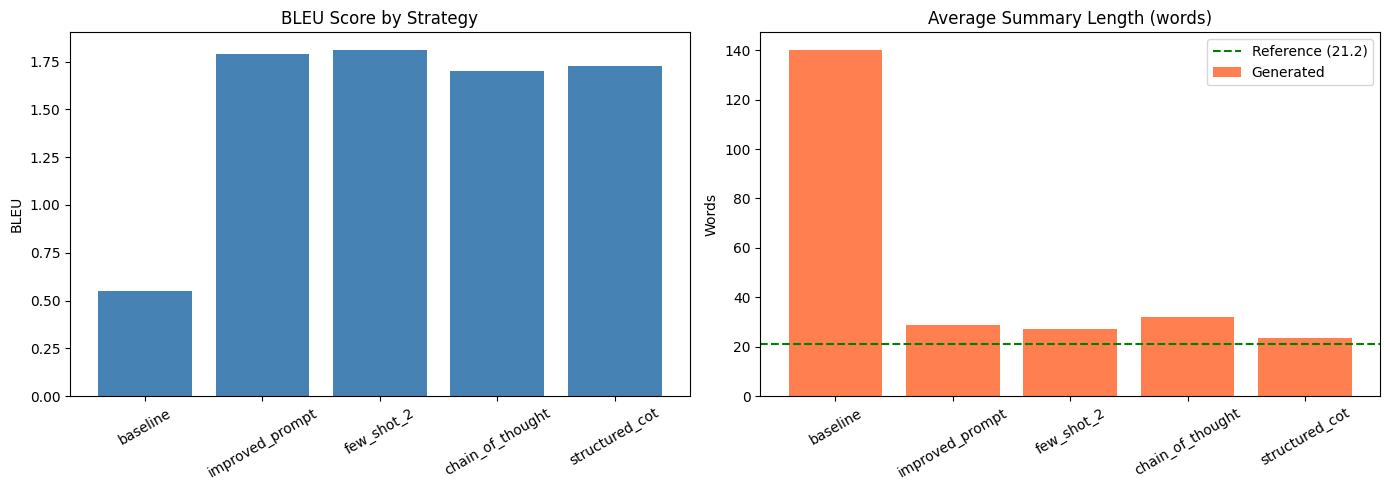

In [ ]:
### YOUR CODE HERE

def create_prompt_baseline(document):
    return f"Summarize the following document: {document} Summary: "

def create_prompt_improved(document):
    return create_prompt_v2(document)

def create_prompt_fewshot_2(document):
    return create_prompt_fewshot(document, n_examples=2)

def create_prompt_cot_wrap(document):
    return create_prompt_cot(document)

def create_prompt_structured_cot_wrap(document):
    return create_prompt_structured_cot(document, n_examples=1)

# Dictionary of strategies to evaluate
strategies = {
    "baseline": (create_prompt_baseline, "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."),
    "improved_prompt": (create_prompt_improved, best_system_prompt),
    "few_shot_2": (create_prompt_fewshot_2, best_system_prompt),
    "chain_of_thought": (create_prompt_cot_wrap, best_system_prompt),
    "structured_cot": (create_prompt_structured_cot_wrap, best_system_prompt),
}

reference_summaries_test = [example["summary"] for example in ds["test"]]
ref_avg_len = calculate_average_length(reference_summaries_test)

results = {}
bleu_metric = sacrebleu.BLEU()

for strategy_name, (prompt_fn, sys_prompt) in strategies.items():
    print(f"\n>>> Evaluating strategy: {strategy_name}")
    generated = generate_summary(
        ds["test"], model, tokenizer, prompt_fn,
        batch_size=8, system_prompt=sys_prompt
    )

    # For CoT strategies, extract the summary portion
    if "cot" in strategy_name or "chain" in strategy_name:
        generated = [extract_summary_from_cot(g) for g in generated]

    avg_len = calculate_average_length(generated)
    bleu = bleu_metric.corpus_score(hypotheses=generated, references=[reference_summaries_test])
    results[strategy_name] = {
        "avg_length": avg_len,
        "bleu": bleu.score,
        "generated": generated
    }
    print(f"  Avg length: {avg_len:.1f} (reference: {ref_avg_len:.1f})")
    print(f"  BLEU score: {bleu.score:.2f}")

# Summary table
print("\n" + "=" * 60)
print(f"{'Strategy':<20} {'Avg Length':>12} {'BLEU':>10}")
print("-" * 60)
print(f"{'Reference':<20} {ref_avg_len:>12.1f} {'---':>10}")
for name, res in results.items():
    print(f"{name:<20} {res['avg_length']:>12.1f} {res['bleu']:>10.2f}")
print("=" * 60)

# Bar chart comparing BLEU scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
bleu_scores = [results[n]["bleu"] for n in names]
avg_lengths = [results[n]["avg_length"] for n in names]

axes[0].bar(names, bleu_scores, color="steelblue")
axes[0].set_title("BLEU Score by Strategy")
axes[0].set_ylabel("BLEU")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(names, avg_lengths, color="coral", label="Generated")
axes[1].axhline(y=ref_avg_len, color="green", linestyle="--", label=f"Reference ({ref_avg_len:.1f})")
axes[1].set_title("Average Summary Length (words)")
axes[1].set_ylabel("Words")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

### YOUR CODE ENDS HERE


We used Claude for generating visualizations and creating the table alongside already used methodologies
